In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

In [13]:
data_dir = 'dataset'

datagen= ImageDataGenerator(rescale=1./255,validation_split=0.2)

train_generator= datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    color_mode='rgb',
    batch_size=32,
    class_mode='binary',
    subset='training' 
)

validation_generator= datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    color_mode='rgb',
    batch_size=32,
    class_mode='binary',
    subset='validation' 
)

Found 10942 images belonging to 2 classes.
Found 2735 images belonging to 2 classes.


In [17]:
base = tf.keras.applications.MobileNet(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable=False
model = models.Sequential(
    [base,
    layers.Flatten(),
    layers.Dense(32),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    
    layers.Dense(1,activation='sigmoid')]
)

In [18]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [19]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    steps_per_epoch=50,
)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.6282 - loss: 0.7380 - val_accuracy: 0.7342 - val_loss: 0.6937
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.7956 - loss: 0.4493 - val_accuracy: 0.7707 - val_loss: 0.4858
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.8330 - loss: 0.3835 - val_accuracy: 0.7993 - val_loss: 0.4188
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 168s 3s/step - accuracy: 0.8576 - loss: 0.3176 - val_accuracy: 0.8113 - val_loss: 0.3910
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.8805 - loss: 0.2925 - val_accuracy: 0.8194 - val_loss: 0.3912
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.8969 - loss: 0.2610 - val_accuracy: 0.8314 - val_loss: 0.3634
Epoch 7/30
42/50 ━━━━━━━━━━━━━━━━━━━━ 5s 647ms/step - accuracy: 0.8810 - loss: 0.2774

C:\Users\chatt\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.8835 - loss: 0.2754 - val_accuracy: 0.8333 - val_loss: 0.3543
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - accuracy: 0.9038 - loss: 0.2560 - val_accuracy: 0.8424 - val_loss: 0.3418
Epoch 9/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.9142 - loss: 0.2140 - val_accuracy: 0.8622 - val_loss: 0.3268
Epoch 10/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.9160 - loss: 0.2172 - val_accuracy: 0.8574 - val_loss: 0.3299
Epoch 11/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.9552 - loss: 0.1576 - val_accuracy: 0.8581 - val_loss: 0.3182
Epoch 12/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9433 - loss: 0.1621 - val_accuracy: 0.8494 - val_loss: 0.3452
Epoch 13/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.9492 - loss: 0.1589 - val_accuracy: 0.8662 - val_loss: 0.3116
Epoch 14/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9437 - loss: 0.1464 - val_accuracy: 0.8574 - val_loss: 0

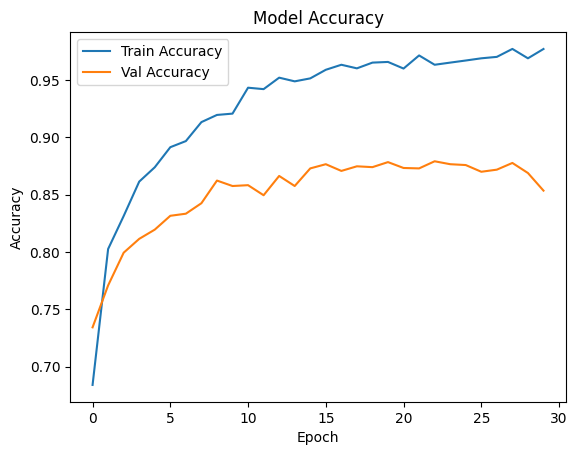

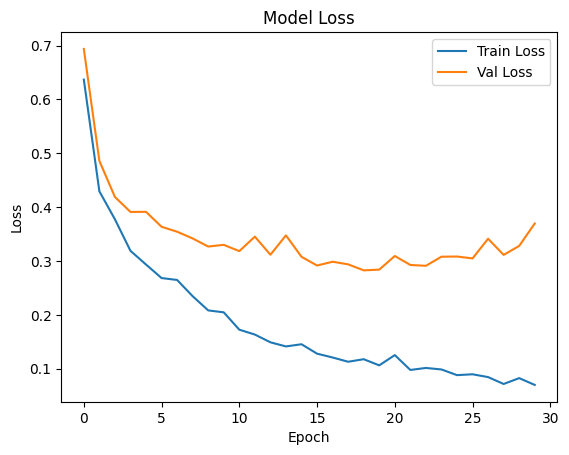

In [20]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()